# Diabetic Retinopathy — Dual-Track Ensemble Notebook

**Tracks implemented in this notebook:**
| Track | Architecture | Pretrained | Output |
|-------|-------------|-----------|--------|
| **Custom** | `CustomCNN × 2` + `VGG16-BN` (from scratch) | ✗ | `output_custom.csv` |
| **Fine-tune** | `EfficientNet-B2` + `DenseNet-121` + `TinyViT-21M` | ✓ | `output_ft.csv` |

**Metric:** AUC (area under the ROC curve)  
**Submission:** `results/outputs/c{AUC_custom}_ft{AUC_ft}_{date}.zip`

---
## Pipeline overview
```
data/train.csv + images/
     │
     ▼
RetinopathyDataset  ──  right-eye mirror · CLAHE · intensity-scaled augmentations
WeightedRandomSampler  ──  balance DR vs No-DR
     │
     ├── [CustomConfig]   EnsembleModel(['CustomCNN','CustomCNN','vgg16_bn'], pretrained=False)
     │                         └── Trainer (BCEWithLogitsLoss on member logits)
     │
     └── [FineTuneConfig] EnsembleModel(['efficientnet_b2','densenet121','tiny_vit_21m_...'], pretrained=True)
                               └── Trainer (BCELoss on averaged probabilities)
                                         ▼
                               results/outputs/{custom,ft}.csv
                               results/c{AUC}_ft{AUC}_{date}.zip
```

---
## 0 · Imports & reproducibility

In [2]:
%matplotlib inline
from __future__ import print_function, division

import os, sys, random, csv, warnings
from datetime import datetime
from zipfile import ZipFile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn import metrics

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# ── Project imports ──────────────────────────────────────────────────────────
from utils.config import Config, CustomConfig, FineTuneConfig
from utils.data_processing import (
    RetinopathyDataset, get_dataloader,
    build_train_transforms, build_eval_transforms,
)
from src.model import BaseModel, EnsembleModel
from src.model_components import CustomCNN
from utils.trainer import Trainer

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = Config.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'Device  : {Config.device}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed    : {SEED}')

Device  : cuda
PyTorch : 2.10.0+cu128
Seed    : 42


---
## 1 · Exploratory Data Analysis (EDA)

In [3]:
# ── Load split CSVs ──────────────────────────────────────────────────────────
train_df = pd.read_csv(Config.train_csv, dtype={'id': str, 'eye': int, 'label': int})
val_df   = pd.read_csv(Config.val_csv,   dtype={'id': str, 'eye': int, 'label': int})
test_df  = pd.read_csv(Config.test_csv,  dtype={'id': str, 'eye': int, 'label': int})

print(f'Train : {len(train_df):>5,} samples')
print(f'Val   : {len(val_df):>5,} samples')
print(f'Test  : {len(test_df):>5,} samples')
train_df.head()

Train : 2,000 samples
Val   :   500 samples
Test  : 1,000 samples


,id,eye,label
0,00000,0,0
1,00001,1,0
2,00002,1,2
3,00003,1,0
4,00004,0,0


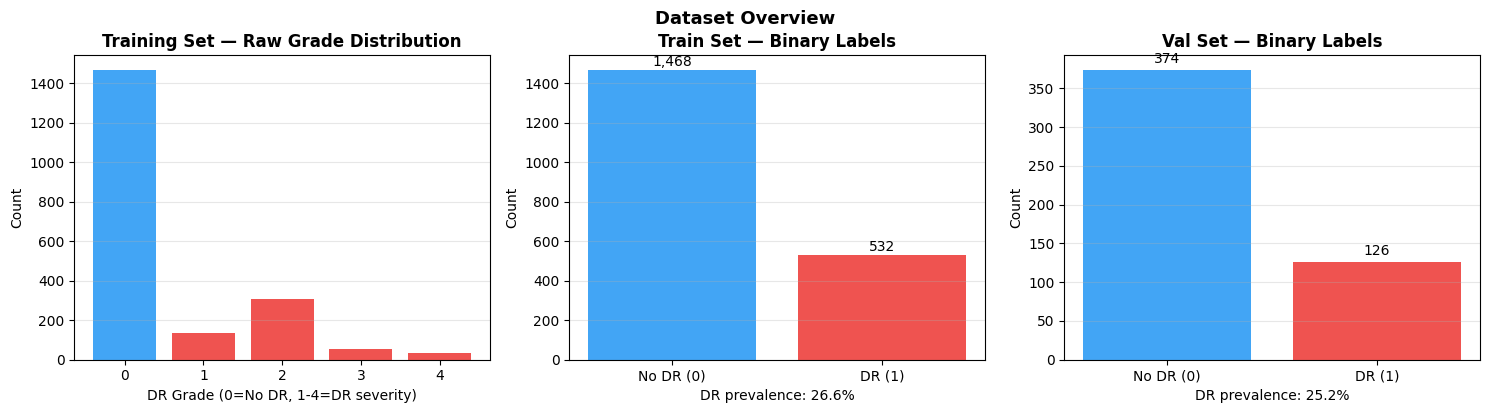


Eye distribution (train):
               No DR   DR
Left eye (0)     730  267
Right eye (1)    738  265


In [4]:
# ── Class distribution ───────────────────────────────────────────────────────
def binary_labels(df):
    return (df['label'].clip(lower=0) > 0).astype(int)

train_bin = binary_labels(train_df)
val_bin   = binary_labels(val_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw grade distribution
grade_counts = train_df['label'].value_counts().sort_index()
axes[0].bar(grade_counts.index.astype(str), grade_counts.values,
            color=['#42A5F5' if i == 0 else '#EF5350' for i in grade_counts.index])
axes[0].set_xlabel('DR Grade (0=No DR, 1-4=DR severity)')
axes[0].set_ylabel('Count')
axes[0].set_title('Training Set — Raw Grade Distribution', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Binary distribution — train
splits = {'Train': train_bin, 'Val': val_bin}
split_palette = ['#42A5F5', '#EF5350']  # blue=No-DR, red=DR
for ax, (name, labels) in zip(axes[1:], splits.items()):
    counts = labels.value_counts().sort_index()
    bars   = ax.bar(['No DR (0)', 'DR (1)'], counts.values, color=split_palette)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Set — Binary Labels', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    pos_pct = counts.iloc[1] / counts.sum() * 100 if len(counts) > 1 else 0
    ax.set_xlabel(f'DR prevalence: {pos_pct:.1f}%')

plt.tight_layout()
plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.show()

# ── Eye distribution ─────────────────────────────────────────────────────────
eye_counts = train_df.groupby(['eye', train_bin]).size().unstack(fill_value=0)
eye_counts.index = ['Left eye (0)', 'Right eye (1)']
eye_counts.columns = ['No DR', 'DR']
print('\nEye distribution (train):')
print(eye_counts)

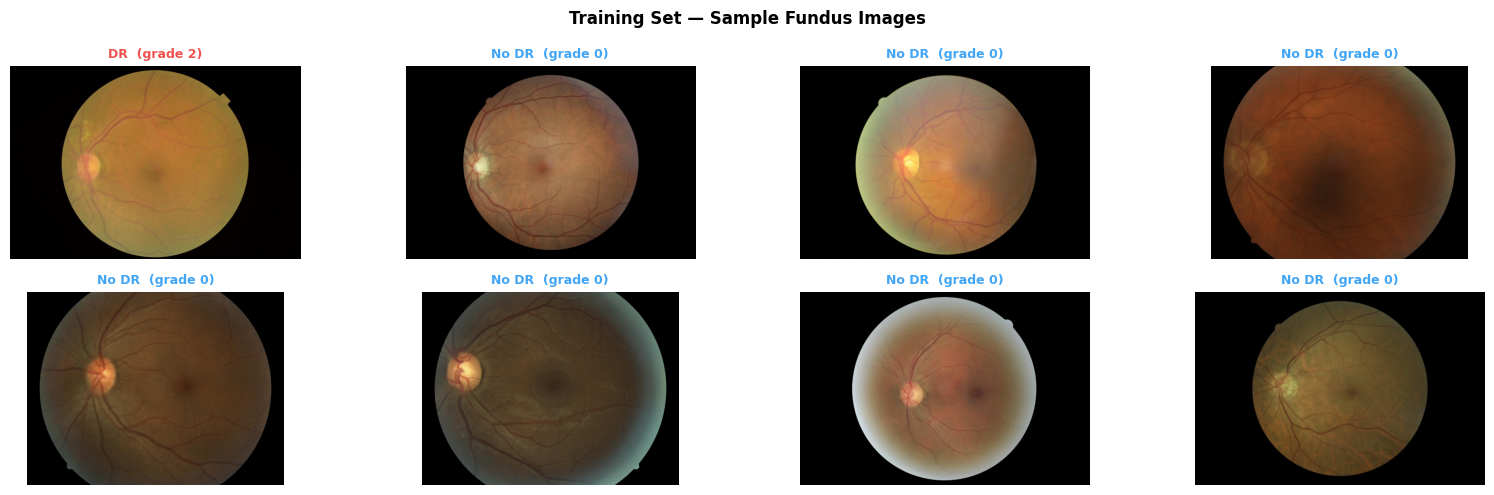

In [5]:
# ── Visualise sample fundus images ───────────────────────────────────────────
import skimage.io as skio
import skimage.util as skutil

IMG_DIR = Config.images_dir

def show_samples(df, title, n=8):
    """Show n random fundus images from a DataFrame split."""
    sample = df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(16, 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        path = os.path.join(IMG_DIR, row['id'] + '.jpg')
        if not os.path.exists(path):
            axes[i].text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                         transform=axes[i].transAxes, fontsize=9, color='grey')
            axes[i].set_xticks([]); axes[i].set_yticks([])
            continue
        img = skio.imread(path)
        if row['eye'] == 1:
            img = img[:, ::-1, :]
        axes[i].imshow(img)
        label_str = 'DR' if row['label'] > 0 else 'No DR'
        color     = '#EF5350' if row['label'] > 0 else '#42A5F5'
        axes[i].set_title(f'{label_str}  (grade {row["label"]})',
                          color=color, fontsize=9, fontweight='bold')
        axes[i].axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_df, 'Training Set — Sample Fundus Images', n=8)

---
## 2 · Track A — Custom CNN Ensemble (from scratch)

**Architecture:** `CustomCNN × 2` + `VGG16-BN` — *no pretrained weights*  
**Key difference from fine-tuning:** all parameters are randomly initialised;
higher learning rate, stronger augmentation, and longer patience are used.

In [6]:
# ── Config summary ────────────────────────────────────────────────────────────
custom_cfg = CustomConfig

print('='*55)
print('  CUSTOM TRACK — CONFIG')
print('='*55)
for attr in ['pretrained','aug_intensity','unfreeze_layers','num_epochs',
             'learning_rate','weight_decay','early_stopping','batch_size',
             'aug_rigid','aug_regularize','aug_clahe']:
    print(f'  {attr:<20} : {getattr(custom_cfg, attr)}')
print('='*55)

  CUSTOM TRACK — CONFIG
  pretrained           : False
  aug_intensity        : 0.9
  unfreeze_layers      : -1
  num_epochs           : 60
  learning_rate        : 0.0005
  weight_decay         : 0.0005
  early_stopping       : 15
  batch_size           : 32
  aug_rigid            : True
  aug_regularize       : True
  aug_clahe            : True


In [7]:
# ── Build DataLoaders (custom config) ────────────────────────────────────────
os.makedirs(custom_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(custom_cfg.output_dir, exist_ok=True)

custom_train_ds, custom_train_loader = get_dataloader(
    csv_file      = str(custom_cfg.train_csv),
    root_dir      = str(custom_cfg.data_dir),
    is_train      = True,
    batch_size    = custom_cfg.batch_size,
    aug_intensity = custom_cfg.aug_intensity,
)

custom_val_ds, custom_val_loader = get_dataloader(
    csv_file   = str(custom_cfg.val_csv),
    root_dir   = str(custom_cfg.data_dir),
    is_train   = False,
    batch_size = custom_cfg.batch_size,
)

_, custom_test_loader = get_dataloader(
    csv_file   = str(custom_cfg.test_csv),
    root_dir   = str(custom_cfg.data_dir),
    is_train   = False,
    batch_size = custom_cfg.batch_size,
)

print(f'\nTrain batches : {len(custom_train_loader)}')
print(f'Val   batches : {len(custom_val_loader)}')
print(f'Test  batches : {len(custom_test_loader)}')

[DataLoader] train.csv | No-DR: 1,468 | DR: 532 | WeightedSampler ratio ≈ 1:2.76

Train batches : 62
Val   batches : 16
Test  batches : 32


In [8]:
# ── Build Custom Ensemble ────────────────────────────────────────────────────
#  Three diverse from-scratch architectures:
#    • 2× CustomCNN  — the bespoke lightweight CNN
#    • 1× VGG16-BN   — classic deep CNN with BN (no pretrained weights)
#
#  Using two CustomCNN members gives diversity through different random inits;
#  VGG16-BN adds a deeper feature extractor with a different inductive bias.

custom_ensemble = EnsembleModel(
    backbone_names = ['CustomCNN', 'CustomCNN', 'vgg16_bn'],
    unfreeze_n     = custom_cfg.unfreeze_layers,   # -1 → all trainable
    pretrained     = custom_cfg.pretrained,         # False
)
custom_ensemble = custom_ensemble.to(custom_cfg.device)
print(f'\nMember names : {custom_ensemble.member_names}')

[CustomCNN] img_size=224 | flat=93,312 | total=11,949,281  trainable=11,949,281
[CustomCNN] img_size=224 | flat=93,312 | total=11,949,281  trainable=11,949,281
[BaseModel] vgg16_bn | total=134,273,089  trainable=134,273,089
[EnsembleModel] Members: ['CustomCNN', 'CustomCNN', 'vgg16_bn']
[EnsembleModel] Total trainable params: 158,171,651

Member names : ['CustomCNN', 'CustomCNN', 'vgg16_bn']


In [10]:
# ── Trainer (custom) ─────────────────────────────────────────────────────────
custom_trainer = Trainer(
    model          = custom_ensemble,
    train_loader   = custom_train_loader,
    val_loader     = custom_val_loader,
    lr             = custom_cfg.learning_rate,
    weight_decay   = custom_cfg.weight_decay,
    device         = custom_cfg.device,
    checkpoint_dir = str(custom_cfg.checkpoint_dir),
)

[Trainer] Auto pos_weight: 1022 neg / 962 pos = 1.062
[Trainer] pos_weight = 1.0624
[Trainer] Loss: BCELoss  (EnsembleModel returns probabilities)


In [ ]:
# ── Train custom ensemble ─────────────────────────────────────────────────────
custom_history = custom_trainer.fit(
    num_epochs      = custom_cfg.num_epochs,
    early_stopping  = custom_cfg.early_stopping,
    checkpoint_name = 'best_custom.pth',
)

### 2.1 · Custom — Training curves

In [ ]:
def plot_training_curves(history: dict, title: str = 'Training curves'):
    """Plot loss and AUC curves for both splits."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # AUC
    axes[1].plot(epochs, history['train_auc'], 'b-o', ms=3, label='Train')
    axes[1].plot(epochs, history['val_auc'],   'r-o', ms=3, label='Val')
    best_e  = int(np.argmax(history['val_auc'])) + 1
    best_v  = max(history['val_auc'])
    axes[1].axvline(best_e, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch {best_e}  AUC={best_v:.4f}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
    axes[1].set_title('ROC-AUC', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_curves(custom_history, 'Custom CNN Ensemble — Training Curves')

### 2.2 · Custom — Validation analysis

In [ ]:
# ── Load best custom weights and evaluate ────────────────────────────────────
custom_trainer.load_best(checkpoint_name='best_custom.pth')
custom_auc, custom_labels, custom_probs = custom_trainer.evaluate(custom_val_loader)
print(f'Custom ensemble  →  Val AUC: {custom_auc:.4f}')

In [ ]:
def plot_roc_and_hist(labels, probs, title_prefix: str):
    """ROC curve + score histogram side by side."""
    fpr, tpr, thresholds = metrics.roc_curve(labels, probs)
    auc_val = metrics.roc_auc_score(labels, probs)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ROC
    axes[0].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'AUC = {auc_val:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set(xlim=[-0.01, 1.01], ylim=[-0.01, 1.02],
                xlabel='FPR', ylabel='TPR',
                title=f'{title_prefix} — ROC Curve')
    axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

    # Score distribution
    axes[1].hist(probs[labels == 0], bins=40, alpha=0.6,
                 color='#2196F3', label='No DR', density=True)
    axes[1].hist(probs[labels == 1], bins=40, alpha=0.6,
                 color='#F44336', label='DR',    density=True)
    axes[1].set(xlabel='Predicted DR probability', ylabel='Density',
                title=f'{title_prefix} — Score Distribution')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Optimal threshold (Youden's J)
    j_idx  = np.argmax(tpr - fpr)
    thresh = thresholds[j_idx]
    preds  = (probs >= thresh).astype(int)
    cm     = metrics.confusion_matrix(labels, preds)
    print(f'Optimal threshold (Youden J): {thresh:.4f}')
    print(f'  TPR: {tpr[j_idx]:.4f}   FPR: {fpr[j_idx]:.4f}')
    print('\nConfusion matrix at optimal threshold:')
    print(pd.DataFrame(cm, index=['True No-DR','True DR'],
                       columns=['Pred No-DR','Pred DR']))
    print(f'\nClassification report:')
    print(metrics.classification_report(labels, preds,
                                        target_names=['No DR', 'DR']))
    return fpr, tpr, thresh

c_fpr, c_tpr, c_thresh = plot_roc_and_hist(
    custom_labels, custom_probs, 'Custom CNN Ensemble')

In [ ]:
# ── Per-member AUC breakdown (custom) ────────────────────────────────────────
print('Per-backbone validation AUC (custom ensemble):')
custom_ensemble.eval()
member_probs_c = [[] for _ in range(len(custom_ensemble.member_names))]
all_labs_c     = []

with torch.no_grad():
    for batch in custom_val_loader:
        inputs = batch['image'].to(custom_cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labs_c.extend(labs)
        logits = custom_ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            member_probs_c[k].extend(
                torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist())

all_labs_c = np.array(all_labs_c)
for name, probs_k in zip(custom_ensemble.member_names, member_probs_c):
    auc_k = metrics.roc_auc_score(all_labs_c, np.array(probs_k))
    print(f'  {name:<30} : {auc_k:.4f}')
print(f'  {"Ensemble (avg)":<30} : {custom_auc:.4f}  ← should beat all individual members')

---
## 3 · Track B — Fine-Tuning Ensemble (pretrained)

**Architecture:** `EfficientNet-B2` + `DenseNet-121` + `TinyViT-21M` — *ImageNet pretrained*  
**Strategy:** Only the last `unfreeze_layers=2` layer groups are updated initially;
the backbone is used as a strong feature extractor.

In [ ]:
# ── Config summary ────────────────────────────────────────────────────────────
ft_cfg = FineTuneConfig

print('='*55)
print('  FINE-TUNE TRACK — CONFIG')
print('='*55)
for attr in ['pretrained','aug_intensity','unfreeze_layers','num_epochs',
             'learning_rate','weight_decay','early_stopping','batch_size',
             'aug_rigid','aug_regularize','aug_clahe']:
    print(f'  {attr:<20} : {getattr(ft_cfg, attr)}')
print('='*55)

In [ ]:
# ── Build DataLoaders (fine-tune config) ─────────────────────────────────────
os.makedirs(ft_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(ft_cfg.output_dir, exist_ok=True)

ft_train_ds, ft_train_loader = get_dataloader(
    csv_file      = str(ft_cfg.train_csv),
    root_dir      = str(ft_cfg.data_dir),
    is_train      = True,
    batch_size    = ft_cfg.batch_size,
    aug_intensity = ft_cfg.aug_intensity,
)

ft_val_ds, ft_val_loader = get_dataloader(
    csv_file   = str(ft_cfg.val_csv),
    root_dir   = str(ft_cfg.data_dir),
    is_train   = False,
    batch_size = ft_cfg.batch_size,
)

_, ft_test_loader = get_dataloader(
    csv_file   = str(ft_cfg.test_csv),
    root_dir   = str(ft_cfg.data_dir),
    is_train   = False,
    batch_size = ft_cfg.batch_size,
)

print(f'\nTrain batches : {len(ft_train_loader)}')
print(f'Val   batches : {len(ft_val_loader)}')
print(f'Test  batches : {len(ft_test_loader)}')

In [ ]:
# ── Build Fine-Tune Ensemble ──────────────────────────────────────────────────
#  Three complementary pretrained backbones:
#    • EfficientNet-B2   — efficient compound scaling, strong on medical images
#    • DenseNet-121      — dense feature reuse, good gradient flow
#    • TinyViT-21M-224   — vision transformer, captures global context

ft_ensemble = EnsembleModel(
    backbone_names = [
        'efficientnet_b2',
        'densenet121',
        'tiny_vit_21m_224.dist_in22k_ft_in1k',
    ],
    unfreeze_n = ft_cfg.unfreeze_layers,
    pretrained = ft_cfg.pretrained,     # True
)
ft_ensemble = ft_ensemble.to(ft_cfg.device)
print(f'\nMember names : {ft_ensemble.member_names}')

In [ ]:
# ── Trainer (fine-tune) ───────────────────────────────────────────────────────
ft_trainer = Trainer(
    model          = ft_ensemble,
    train_loader   = ft_train_loader,
    val_loader     = ft_val_loader,
    lr             = ft_cfg.learning_rate,
    weight_decay   = ft_cfg.weight_decay,
    device         = ft_cfg.device,
    checkpoint_dir = str(ft_cfg.checkpoint_dir),
)

In [ ]:
# ── Train fine-tune ensemble ──────────────────────────────────────────────────
ft_history = ft_trainer.fit(
    num_epochs      = ft_cfg.num_epochs,
    early_stopping  = ft_cfg.early_stopping,
    checkpoint_name = 'best_ft.pth',
)

In [ ]:
# ── (Optional) Unfreeze all backbone layers after warm-up ────────────────────
# Uncomment and re-run fit() with a lower LR to squeeze extra performance.
#
# ft_ensemble.unfreeze_all_members()
# ft_trainer.optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, ft_ensemble.parameters()),
#     lr=ft_cfg.learning_rate * 0.1,
#     weight_decay=ft_cfg.weight_decay,
# )
# ft_history_full = ft_trainer.fit(
#     num_epochs=20, early_stopping=7, checkpoint_name='best_ft_full.pth')

### 3.1 · Fine-tune — Training curves

In [ ]:
plot_training_curves(ft_history, 'Fine-Tune Ensemble — Training Curves')

### 3.2 · Fine-tune — Validation analysis

In [ ]:
ft_trainer.load_best(checkpoint_name='best_ft.pth')
ft_auc, ft_labels, ft_probs = ft_trainer.evaluate(ft_val_loader)
print(f'Fine-tune ensemble  →  Val AUC: {ft_auc:.4f}')

In [ ]:
ft_fpr, ft_tpr, ft_thresh = plot_roc_and_hist(
    ft_labels, ft_probs, 'Fine-Tune Ensemble')

In [ ]:
# ── Per-member AUC breakdown (fine-tune) ─────────────────────────────────────
print('Per-backbone validation AUC (fine-tune ensemble):')
ft_ensemble.eval()
member_probs_ft = [[] for _ in range(len(ft_ensemble.member_names))]
all_labs_ft     = []

with torch.no_grad():
    for batch in ft_val_loader:
        inputs = batch['image'].to(ft_cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labs_ft.extend(labs)
        logits = ft_ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            member_probs_ft[k].extend(
                torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist())

all_labs_ft = np.array(all_labs_ft)
for name, probs_k in zip(ft_ensemble.member_names, member_probs_ft):
    auc_k = metrics.roc_auc_score(all_labs_ft, np.array(probs_k))
    print(f'  {name:<45} : {auc_k:.4f}')
print(f'  {"Ensemble (avg)":<45} : {ft_auc:.4f}  ← should beat all individual members')

---
## 4 · Head-to-head comparison: Custom vs Fine-Tune

In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Track':         ['Custom CNN', 'Fine-Tune'],
    'Architecture':  ['CustomCNN×2 + VGG16-BN', 'EfficientNet-B2 + DenseNet-121 + TinyViT'],
    'Pretrained':    [False, True],
    'Val AUC':       [round(custom_auc, 4), round(ft_auc, 4)],
    'Best Epoch':    [custom_trainer.best_epoch, ft_trainer.best_epoch],
    'Epochs Trained':[len(custom_history['val_auc']), len(ft_history['val_auc'])],
})
print(summary.to_string(index=False))
print(f'\n  Δ AUC (Fine-Tune − Custom) = {ft_auc - custom_auc:+.4f}')

In [ ]:
# ── Side-by-side ROC curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC overlay
axes[0].plot(c_fpr,  c_tpr,  '#7B1FA2', lw=2, label=f'Custom  (AUC={custom_auc:.4f})')
axes[0].plot(ft_fpr, ft_tpr, '#0097A7', lw=2, label=f'FineTune (AUC={ft_auc:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlim=[-0.01,1.01],ylim=[-0.01,1.02],
            xlabel='FPR',ylabel='TPR',title='ROC Curves — Comparison')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Val AUC convergence
axes[1].plot(custom_history['val_auc'], '#7B1FA2', lw=2, label='Custom')
axes[1].plot(ft_history['val_auc'],    '#0097A7', lw=2, label='Fine-Tune')
axes[1].set(xlabel='Epoch', ylabel='Val AUC', title='Validation AUC Convergence')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC bar chart
aucs  = [custom_auc, ft_auc]
names = ['Custom\nCNN', 'Fine-Tune']
bars  = axes[2].bar(names, aucs, color=['#7B1FA2','#0097A7'], width=0.5)
for bar, v in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1.05]); axes[2].set_ylabel('Val AUC')
axes[2].set_title('Val AUC Summary'); axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Custom CNN vs Fine-Tune Ensemble', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Score distribution comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (probs, labs, title) in zip(axes, [
    (custom_probs, custom_labels, f'Custom CNN  (AUC={custom_auc:.4f})'),
    (ft_probs,     ft_labels,     f'Fine-Tune   (AUC={ft_auc:.4f})'),
]):
    ax.hist(probs[labs == 0], bins=40, alpha=0.65,
            color='#2196F3', label='No DR', density=True)
    ax.hist(probs[labs == 1], bins=40, alpha=0.65,
            color='#F44336', label='DR',    density=True)
    ax.set(xlabel='Predicted DR probability', ylabel='Density', title=title)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Score Distributions — Validation Set', fontsize=12,
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Generate test predictions & build submission ZIP

In [ ]:
# ── Custom track — test predictions ──────────────────────────────────────────
custom_scores = custom_trainer.test_inference(
    test_loader = custom_test_loader,
    output_path = str(custom_cfg.output_path),
)

print(f'\nCustom  → shape: {custom_scores.shape}   '
      f'range: [{custom_scores.min():.4f}, {custom_scores.max():.4f}]   '
      f'mean: {custom_scores.mean():.4f}')

In [ ]:
# ── Fine-tune track — test predictions ───────────────────────────────────────
ft_scores = ft_trainer.test_inference(
    test_loader = ft_test_loader,
    output_path = str(ft_cfg.output_path),
)

print(f'\nFineTune → shape: {ft_scores.shape}   '
      f'range: [{ft_scores.min():.4f}, {ft_scores.max():.4f}]   '
      f'mean: {ft_scores.mean():.4f}')

In [ ]:
# ── Test score distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (scores, label) in zip(axes, [
    (custom_scores, f'Custom CNN   (n={len(custom_scores)})'),
    (ft_scores,     f'Fine-Tune    (n={len(ft_scores)})'),
]):
    flat = scores.flatten()
    ax.hist(flat, bins=50, color='#7B1FA2', edgecolor='white', linewidth=0.4)
    ax.axvline(flat.mean(), color='red', linestyle='--',
               label=f'Mean={flat.mean():.3f}')
    ax.set(xlabel='DR score', ylabel='Count',
           title=f'Test Score Distribution — {label}')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Test Set Score Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Build submission ZIP ──────────────────────────────────────────────────────
# Format: c{AUC_custom}_ft{AUC_ft}_{YYYYMMDD}.zip

date_str   = datetime.now().strftime('%Y%m%d')
zip_name   = f'c{custom_auc:.4f}_ft{ft_auc:.4f}_{date_str}.zip'
zip_path   = os.path.join(str(Config.results_dir), zip_name)

custom_csv_path = str(custom_cfg.output_path)
ft_csv_path     = str(ft_cfg.output_path)

missing = [p for p in [custom_csv_path, ft_csv_path] if not os.path.exists(p)]
if missing:
    print(f'WARNING: the following output files are missing and will be skipped:')
    for m in missing: print(f'  {m}')

with ZipFile(zip_path, 'w') as zf:
    if os.path.exists(custom_csv_path):
        zf.write(custom_csv_path, arcname='output_custom.csv')
    if os.path.exists(ft_csv_path):
        zf.write(ft_csv_path, arcname='output_ft.csv')

print(f'Submission ZIP created → {zip_path}')
print(f'  Contains: {ZipFile(zip_path).namelist()}')

---
## 6 · Final summary

In [ ]:
print('=' * 65)
print('  DUAL-TRACK ENSEMBLE — FINAL SUMMARY')
print('=' * 65)
print(f'  Device              : {Config.device}')
print(f'  Image size          : {Config.img_height}×{Config.img_width}')
print()
print('  ── Custom Track ────────────────────────────────────────────')
print(f'  Architecture        : {custom_ensemble.member_names}')
print(f'  Pretrained          : {custom_cfg.pretrained}')
print(f'  Aug intensity       : {custom_cfg.aug_intensity}')
print(f'  Epochs trained      : {len(custom_history["val_auc"])}')
print(f'  Best epoch          : {custom_trainer.best_epoch}')
print(f'  Best val AUC        : {custom_trainer.best_val_auc:.4f}')
print(f'  Output CSV          : {custom_cfg.output_path}')
print()
print('  ── Fine-Tune Track ─────────────────────────────────────────')
print(f'  Architecture        : {ft_ensemble.member_names}')
print(f'  Pretrained          : {ft_cfg.pretrained}')
print(f'  Unfreeze last       : {ft_cfg.unfreeze_layers} layer groups')
print(f'  Aug intensity       : {ft_cfg.aug_intensity}')
print(f'  Epochs trained      : {len(ft_history["val_auc"])}')
print(f'  Best epoch          : {ft_trainer.best_epoch}')
print(f'  Best val AUC        : {ft_trainer.best_val_auc:.4f}')
print(f'  Output CSV          : {ft_cfg.output_path}')
print()
print(f'  Submission ZIP      : {zip_path}')
print(f'  Δ AUC (FT − Custom) : {ft_auc - custom_auc:+.4f}')
print('=' * 65)